In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
#step 1 : time-series data(temperature)
data = np.array([30,31,29,32,33,34,35,36,34,33,32,31,30])

In [ ]:
#step 2 : prepare sequences
def create_dataset(data,time_steps=3):
  X,y=[],[]
  for i in range(len(data)-time_steps):
    X.append(data[i:i+time_steps])
    y.append(data[i+time_steps])
  return np.array(X), np.array(y)
X,y=create_dataset(data)

In [ ]:
# step 3: reshape for RNN
X=X.reshape((X.shape[0],X.shape[1],1))

In [ ]:
# step 4: build RNN model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(3,1)),
    Dense(1)

])
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# step 5: train model
model.fit(X,y,epochs=200, verbose=0)

In [ ]:
#step 6 : predict next value
test_input=np.array([33,32,31])
test_input=test_input.reshape((1,3,1))
prediction=model.predict(test_input)
print("Predicted next day temperature:",prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Predicted next day temperature: 18.826626


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


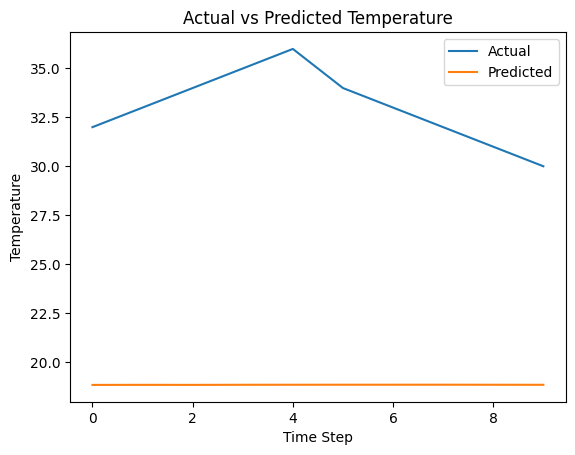

In [ ]:
# graph plot for this sequence(actual vs predicted)
import matplotlib.pyplot as plt

# Generate predictions for the entire dataset X to compare with actual y
predictions = model.predict(X)

plt.figure()
plt.plot(y, label='Actual')
plt.plot(predictions.flatten(), label='Predicted')
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time Step")
plt.ylabel("Temperature")
plt.legend()
plt.show()